# Useful function that allows you to visualise weighting/smoothing schemes

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_weighting_scheme(methods, avg_periods):
    """
    Display graphically the effective weighting applied to a time series
    by multiplying multiple moving averages and exponential weightings.
    
    Parameters:
        methods (list of str): List specifying the type of weighting ('sma' or 'ewm').
        avg_periods (list of float): List of periods corresponding to SMA window sizes or EWM half-lives.
    """
    sum_avg_periods = 0
    for method, period in zip(methods, avg_periods):
        if method == 'sma':
            sum_avg_periods = sum_avg_periods + period

        elif method == 'ewm':
            sum_avg_periods = sum_avg_periods + period * 4
    
    df = pd.DataFrame(0, index=range(-sum_avg_periods,sum_avg_periods), columns=['Values'])
    df.iloc[sum_avg_periods, 0] = 1
    df_fresh = df.copy()
    df_comp = pd.DataFrame(index = df.index)
    
    if len(methods) != len(avg_periods):
        raise ValueError("methods and avg_periods must have the same length.")
    
    for method, period in zip(methods, avg_periods):
        if method == 'sma':
            df = df.rolling(period).mean()
            dfc = df_fresh.rolling(period).mean() 
        elif method == 'ewm':
            df = df.ewm(halflife =period).mean()
            dfc = df_fresh.ewm(halflife =period).mean()
        else:
            raise ValueError("Invalid method. Use 'sma' or 'ewm'.")
        
        dfc.columns = [method + ' ' + str(period)]
        df_comp = pd.concat([df_comp, dfc], axis = 1)

    plt.figure(figsize=(8, 5))
    plt.bar(df.loc[0:].index, df.loc[0:].iloc[:,0], label='Effective Weighting', color='lightskyblue')
    plt.plot(df_comp.loc[0:], label = df_comp.columns.to_list())
    
    plt.title('Effective Weighting Scheme')
    plt.xlabel('Time Steps (Days)')
    plt.ylabel('Weight')
    plt.grid(linestyle = '--', linewidth = 0.5)
    plt.legend()
    plt.show()

# Example usage

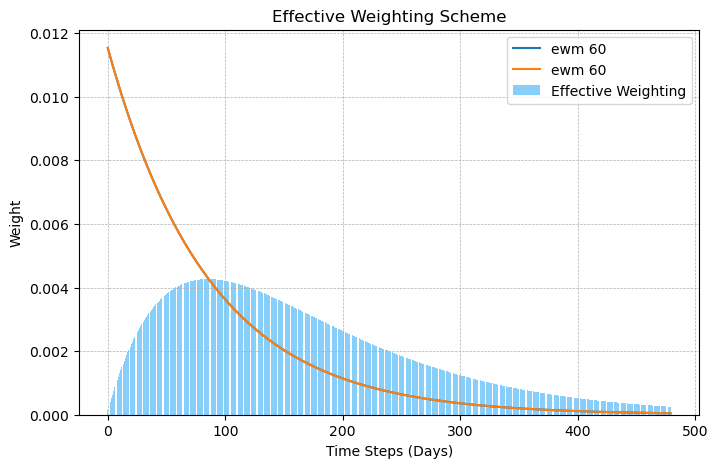

In [4]:
plot_weighting_scheme(['ewm','ewm'], [60, 60])

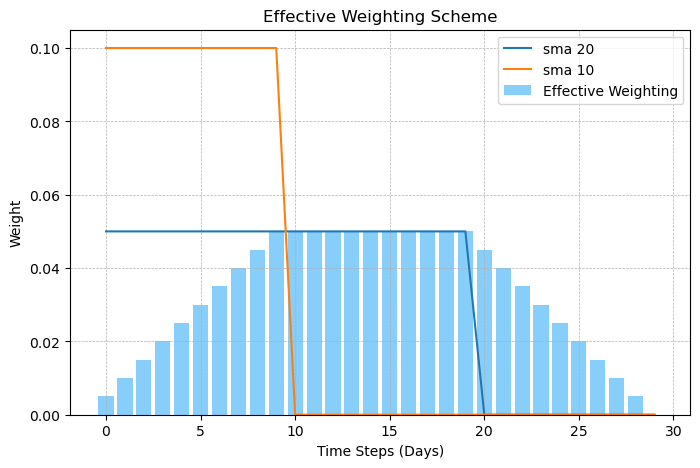

In [5]:
plot_weighting_scheme(['sma','sma'], [20, 10])

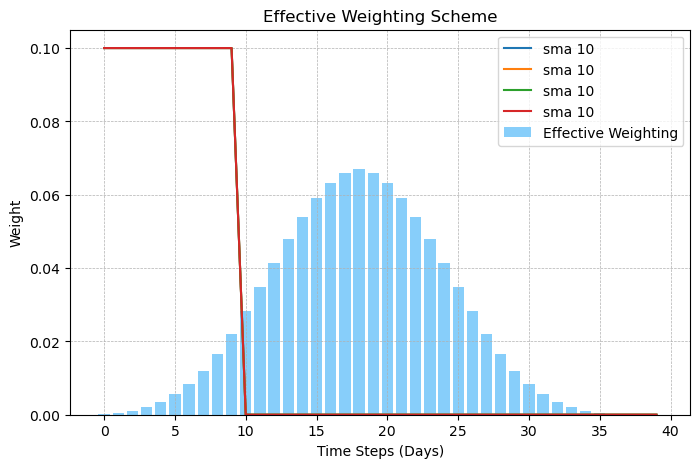

In [6]:
plot_weighting_scheme(['sma','sma','sma','sma'], [10, 10, 10, 10])